In [1]:
import cv2
import numpy as np
import shap
import matplotlib.pyplot as plt
import tensorflow as tf

2025-06-16 08:38:28.670897: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1750063108.852125      35 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1750063108.904896      35 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
def classify_image(preprocessed_image, model):
    # Add batch dimension to the preprocessed image
    X_array = np.expand_dims(preprocessed_image, axis=0)

    # Get model predictions
    predictions = model(X_array)

    # Convert predictions to numpy array
    predictions_np = predictions.numpy()

    # Print the outputs of the final layer
    print("Outputs of the final layer:", predictions_np)

    # Optionally, return the predictions for further use
    return predictions_np

In [3]:
def runScript(path, model):
    img = cv2.imread(path)

    if img is not None:  # Check if the image was loaded successfully
        # Resize the image to (224, 224)
        img_resized = cv2.resize(img, (224, 224))

        # Convert to RGB
        img_rgb = cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB)

        # Normalize image (adjust normalization as per your model's requirements)
        preprocessed_image = img_rgb.astype(np.float32) / 255.0  # Example normalization

        # Add batch dimension for SHAP and model
        X_array = np.expand_dims(preprocessed_image, axis=0)  # Shape: (1, 224, 224, 3)

        # Initialize SHAP masker
        masker = shap.maskers.Image("blur(3,3)", X_array[0].shape)

        # Define model prediction function
        def model_predict(images):
            images = np.array(images)  # Ensure correct format
            predictions = model(images)  # Ensure model can handle this input
            return predictions.numpy()  # Convert tensor to numpy array

        # Class names
        class_names = [ 'normal', 'pcos']

        # Initialize SHAP explainer
        explainer = shap.Explainer(model_predict, masker, output_names=class_names)

        # Compute SHAP values
        shap_values = explainer(X_array, max_evals=20000, batch_size=1)

        # Plot and save SHAP values with large figure
        shap.image_plot(shap_values, show=False)  # Generate the plot but don't show immediately
        plt.gcf().set_size_inches(15, 15)         # Resize the current figure
        plt.suptitle("SHAP Values for Image Classification", fontsize=32)

        # Save the plot to a file
        plt.savefig("/kaggle/working/3originalshap_plot_output.png", dpi=300, bbox_inches='tight')
        plt.show()  # Optionally show it as well

        # Classify the image and print predictions
        prediction = classify_image(preprocessed_image, model)  # Ensure this function is defined
        print("Model Prediction:", prediction)

        # Display the original image with the prediction as title
        plt.figure(figsize=(5, 5))
        plt.imshow(img_rgb)
        plt.title(f"Original Image - Prediction: {prediction}")
        plt.axis('off')
        plt.show()

    else:
        print("Error: Image not found or could not be loaded.")

In [8]:
import tensorflow as tf

# Load the entire model
model = tf.keras.models.load_model('/kaggle/input/densenetpcosnew2/tensorflow2/default/1/DensenetPcosnew2.h5')
path='/kaggle/input/aug2splitpcos/splitAug2PreprocessPcos2000/val/normal/processed_10.jpg'

I0000 00:00:1748690806.466803      35 cuda_dnn.cc:529] Loaded cuDNN version 90300


  0%|          | 0/19998 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [53:47, 3227.34s/it]             


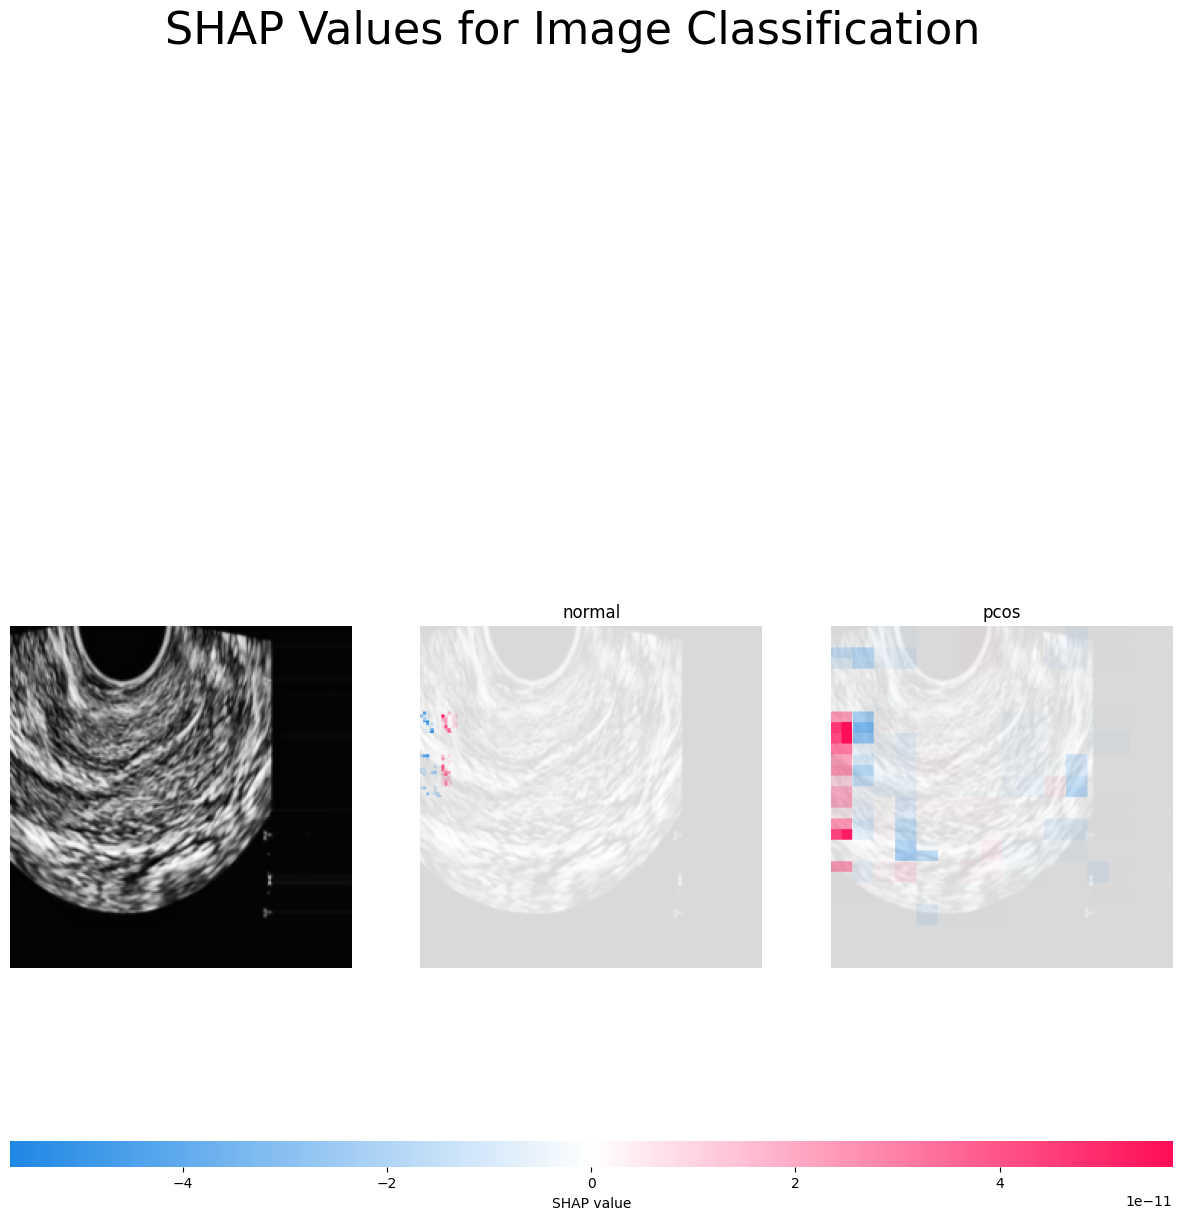

Outputs of the final layer: [[9.9999750e-01 2.5317709e-06]]
Model Prediction: [[9.9999750e-01 2.5317709e-06]]


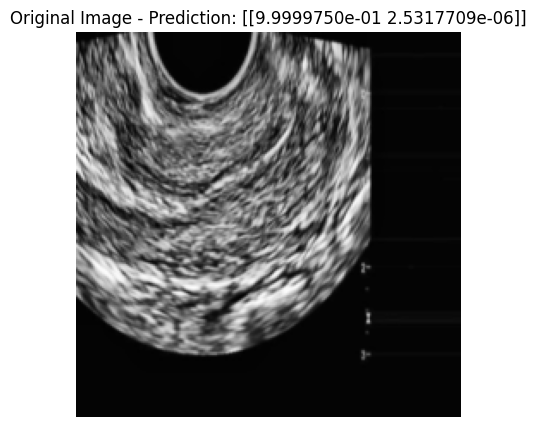

In [9]:
runScript(path, model)

In [1]:
import tensorflow as tf

# Load the entire model
model = tf.keras.models.load_model('/kaggle/input/densenetpcosnew2/tensorflow2/default/1/DensenetPcosnew2.h5')
path='/kaggle/input/aug2splitpcos/splitAug2PreprocessPcos2000/val/normal/processed_1010.jpg'

2025-05-31 13:07:24.618573: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1748696844.803348      35 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1748696844.858257      35 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
I0000 00:00:1748696858.139726      35 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1748696858.140427      35 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability:

I0000 00:00:1748697426.426503      35 cuda_dnn.cc:529] Loaded cuDNN version 90300


  0%|          | 0/19998 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [51:37, 3097.73s/it]             


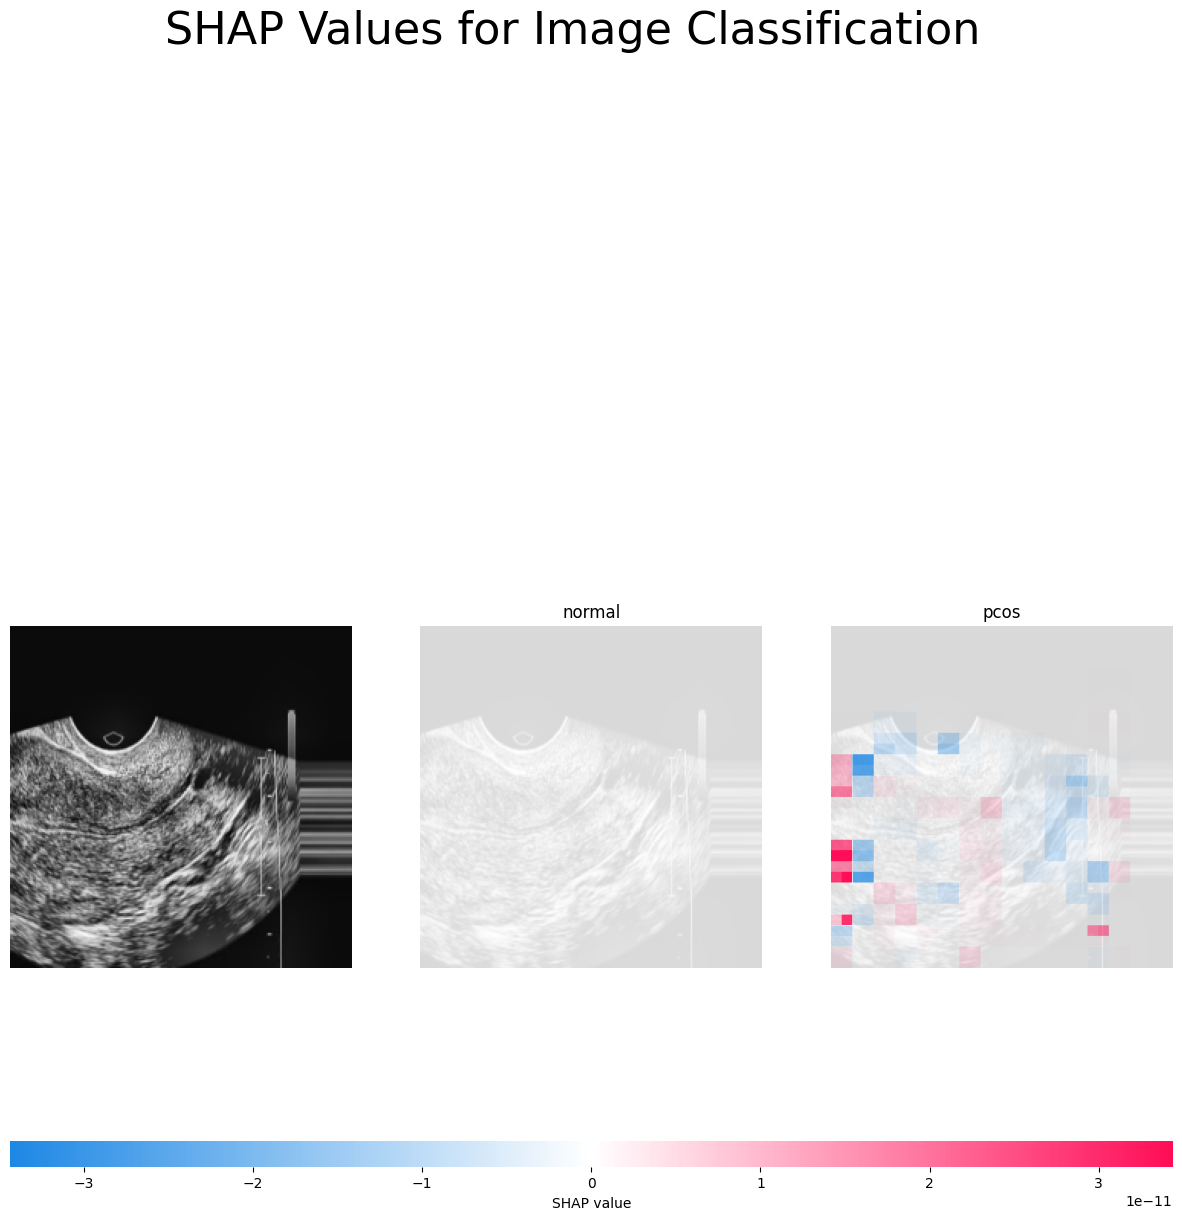

Outputs of the final layer: [[9.9999750e-01 2.4878032e-06]]
Model Prediction: [[9.9999750e-01 2.4878032e-06]]


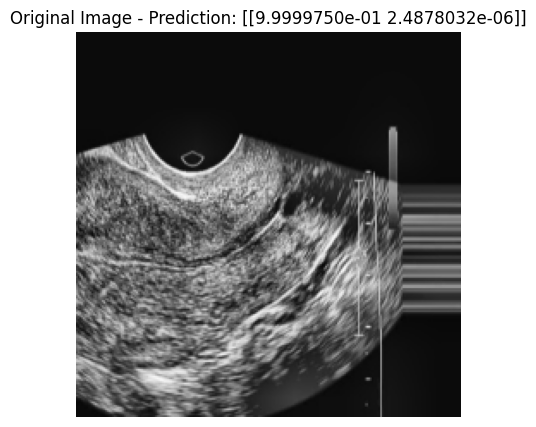

In [7]:
runScript(path, model)

In [4]:
import tensorflow as tf

# Load the entire model
model = tf.keras.models.load_model('/kaggle/input/newdensentclass2/tensorflow2/default/1/densenet121Im (1).h5')
path='/kaggle/input/aug2splitpcos/splitAug2PreprocessPcos2000/val/normal/processed_1010.jpg'

I0000 00:00:1748702547.973918      35 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1748702547.974736      35 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


I0000 00:00:1748702556.575067      35 cuda_dnn.cc:529] Loaded cuDNN version 90300


  0%|          | 0/19998 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [53:50, 3230.43s/it]             


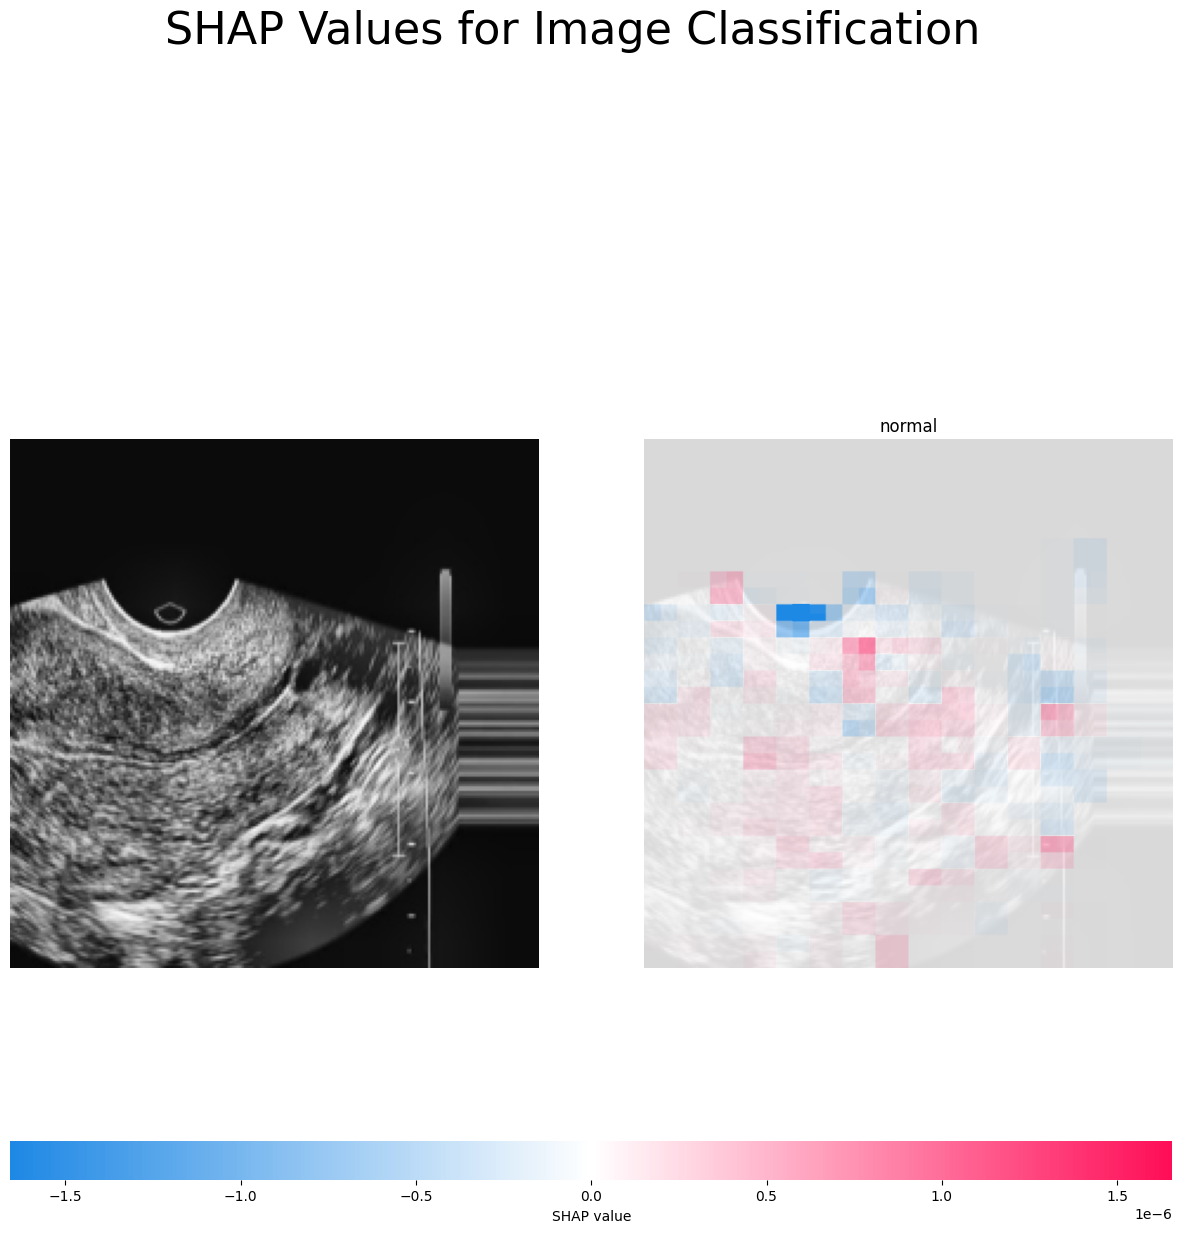

Outputs of the final layer: [[0.00111833]]
Model Prediction: [[0.00111833]]


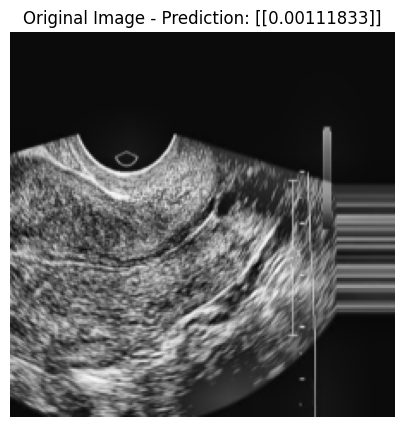

In [5]:
runScript(path, model)

In [9]:
import tensorflow as tf

# Load the entire model
model = tf.keras.models.load_model('/kaggle/input/modelpcosnew/tensorflow2/default/1/fullModel.h5')
path='/kaggle/input/aug2splitpcos/splitAug2PreprocessPcos2000/val/normal/processed_1010.jpg'

  0%|          | 0/19998 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [52:53, 3173.21s/it]             


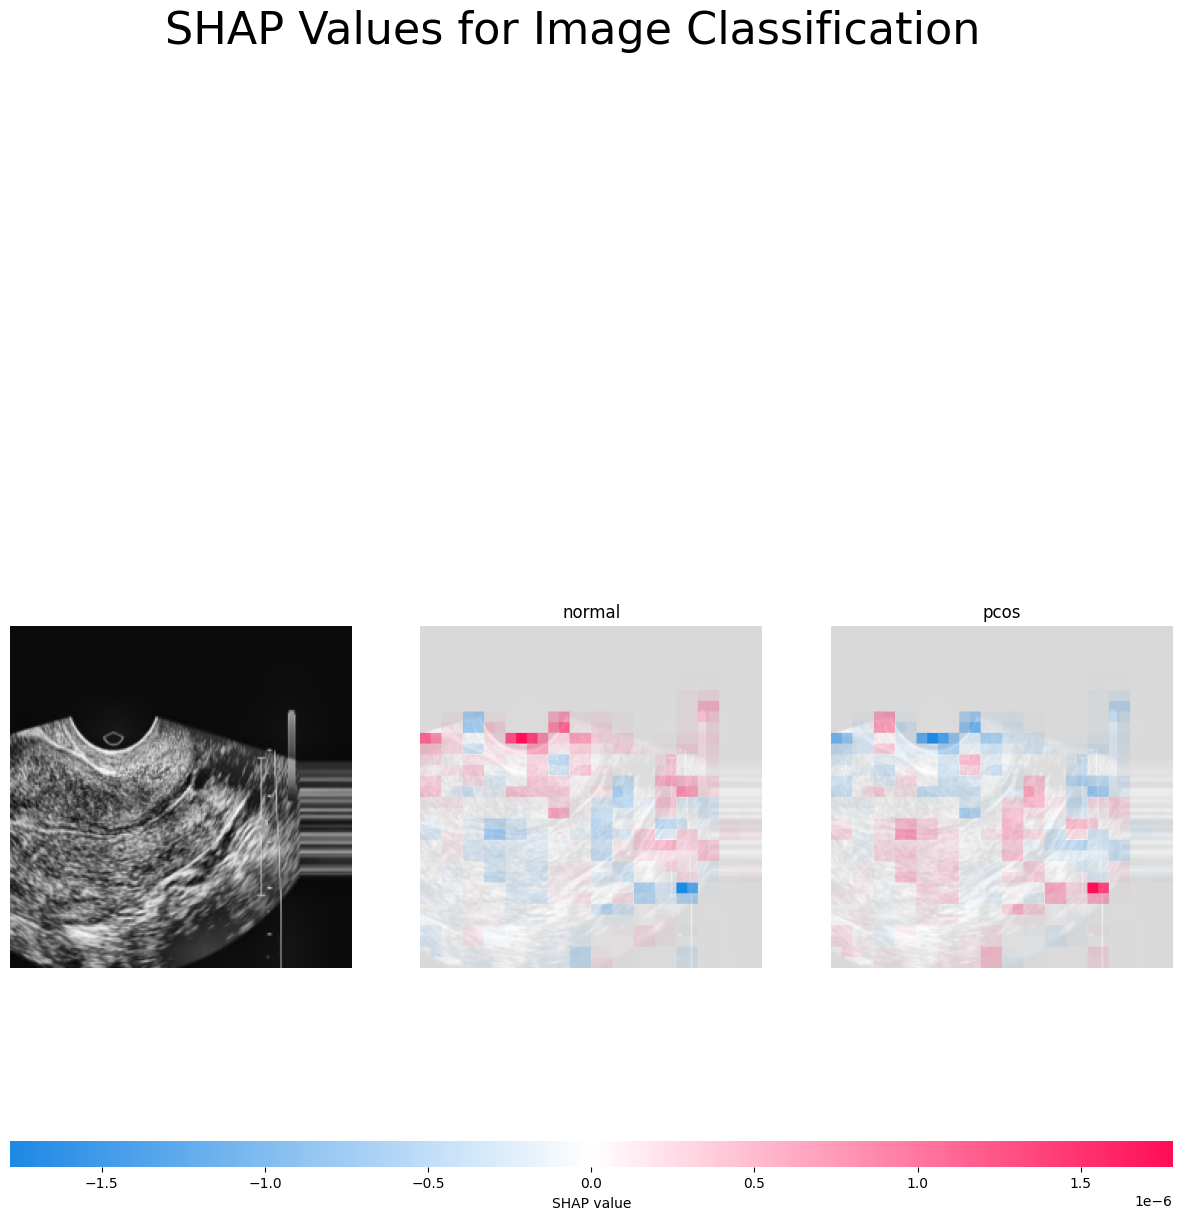

Outputs of the final layer: [[9.9908888e-01 9.1113284e-04]]
Model Prediction: [[9.9908888e-01 9.1113284e-04]]


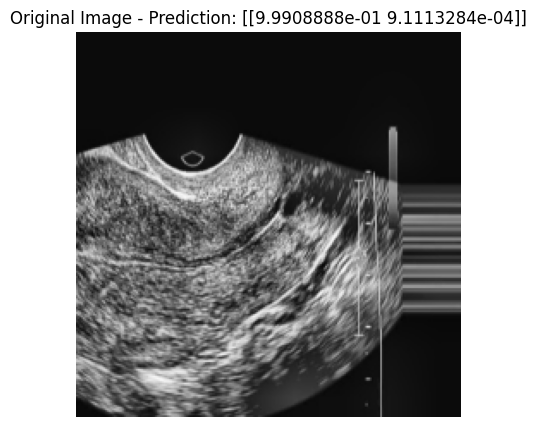

In [10]:
runScript(path, model)

In [4]:
import tensorflow as tf

# Load the entire model
model = tf.keras.models.load_model('/kaggle/input/newdensentclass2/tensorflow2/default/1/densenet121Im (1).h5')
path='/kaggle/input/aug2splitpcos/splitAug2PreprocessPcos2000/val/pcos/processed_1078.jpg'

I0000 00:00:1748843106.604050      35 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1748843106.604799      35 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


I0000 00:00:1748843115.183764      35 cuda_dnn.cc:529] Loaded cuDNN version 90300


  0%|          | 0/19998 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [53:57, 3237.30s/it]             


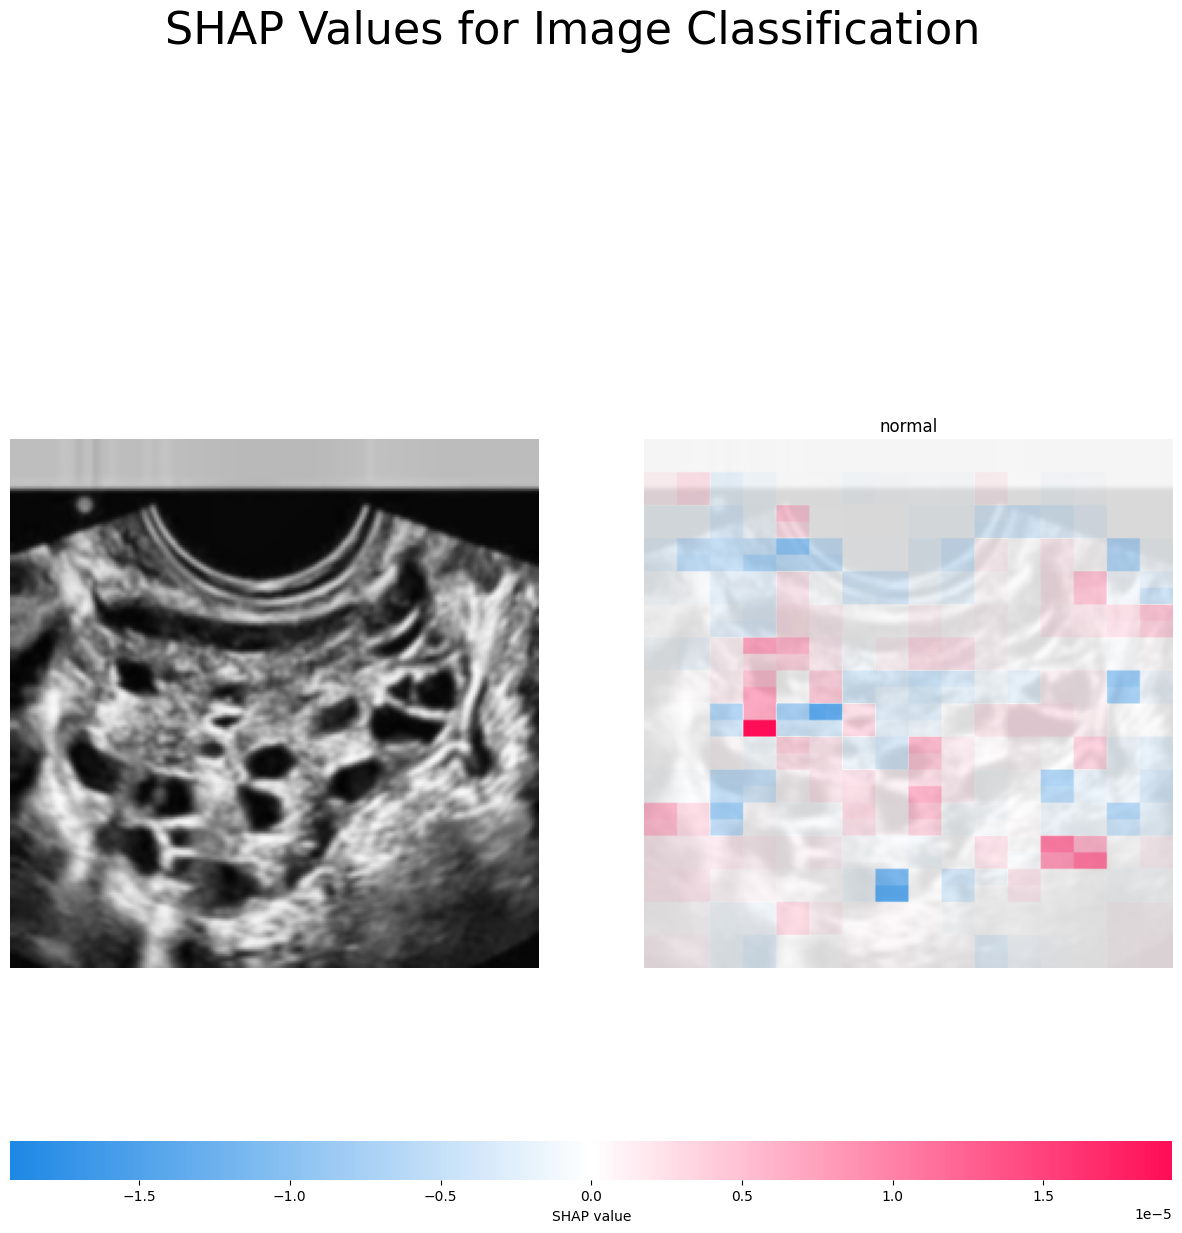

Outputs of the final layer: [[0.03086215]]
Model Prediction: [[0.03086215]]


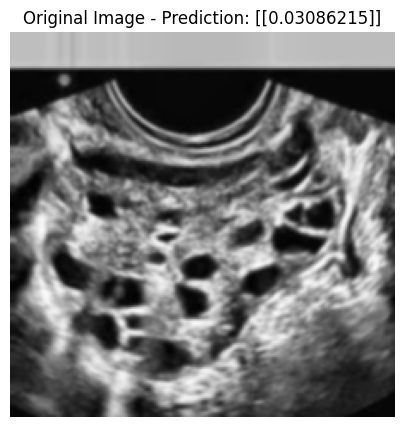

In [5]:
runScript(path, model)

In [4]:
import tensorflow as tf

# Load the entire model
model = tf.keras.models.load_model('/kaggle/input/modelpcosnew/tensorflow2/default/1/fullModel.h5')
path='/kaggle/input/aug2splitpcos/splitAug2PreprocessPcos2000/val/pcos/processed_1078.jpg'

I0000 00:00:1748848598.473963      35 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1748848598.474777      35 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


I0000 00:00:1748848607.639996      35 cuda_dnn.cc:529] Loaded cuDNN version 90300


  0%|          | 0/19998 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [58:37, 3517.71s/it]             


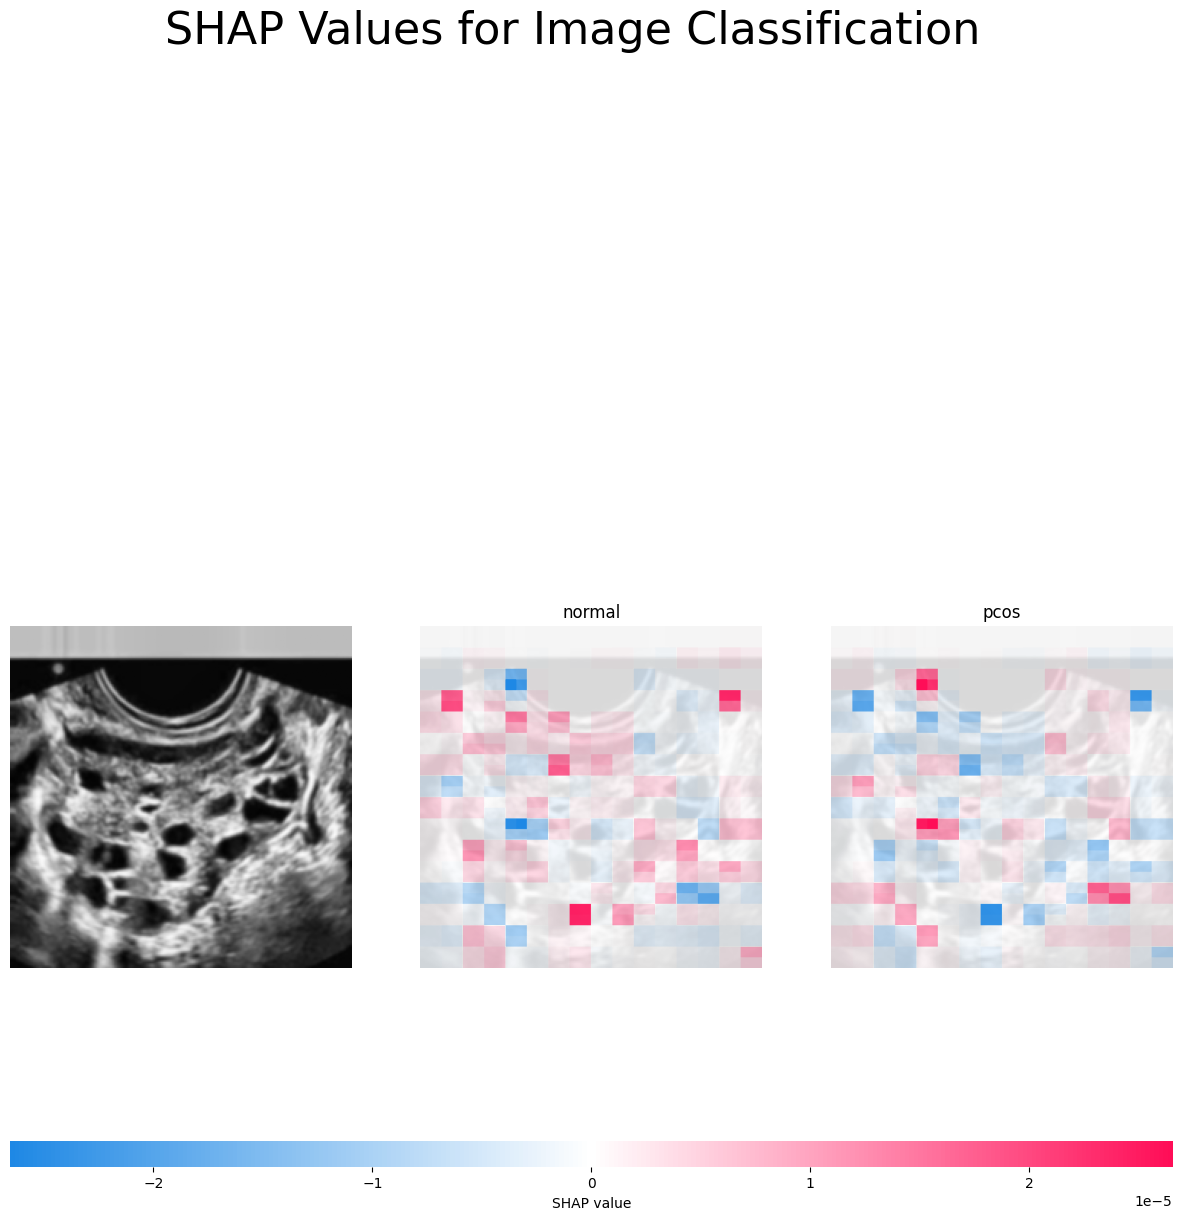

Outputs of the final layer: [[0.93748295 0.06251702]]
Model Prediction: [[0.93748295 0.06251702]]


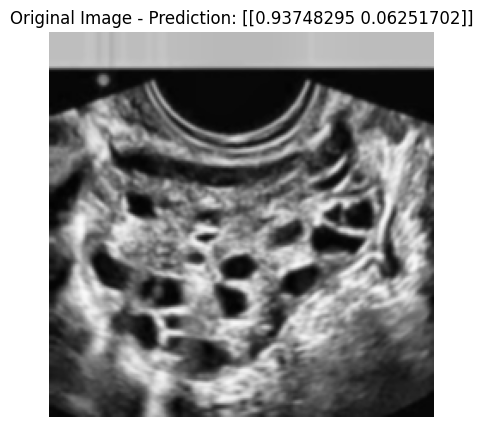

In [5]:
runScript(path, model)

In [ ]:
import tensorflow as tf

# Load the entire model
model = tf.keras.models.load_model('/kaggle/input/efficienntnewcorrectmodel/tensorflow2/default/1/ImportEfficientPcos(New).h5')
path='/kaggle/input/aug2splitpcos/splitAug2PreprocessPcos2000/val/pcos/processed_1078.jpg' 

In [ ]:
runScript(path, model)